# Travel, Tourism & Hospitality

## Customer Retention and Dynamic Pricing Analysis

### Week 2 - Day 2

Hotel Type Analysis

Dataset:
Hotel Booking Demand Dataset

Author:
Niveditha J

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    r"C:\Users\Hp\Desktop\Travel-Tourism-Customer-Retention-Analysis\data\processed\hotel_bookings_validated.csv"
)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay_nights,total_guests,booking_changed,has_previous_cancellation,special_request_flag
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,0,2.0,1,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,0,2.0,1,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,1.0,0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,1.0,0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,98.0,0,1,Check-Out,2015-07-03,2,2.0,0,0,1


In [3]:
df.shape

(87359, 36)

## Hotel Types

The dataset contains two hotel categories:

- City Hotel
- Resort Hotel

This analysis examines booking distribution and cancellation behavior across hotel types.

In [4]:
df['hotel'].value_counts()

hotel
City Hotel      53423
Resort Hotel    33936
Name: count, dtype: int64

In [5]:
hotel_percent = (
    df['hotel']
    .value_counts(normalize=True)
    * 100
)

hotel_percent

hotel
City Hotel      61.153401
Resort Hotel    38.846599
Name: proportion, dtype: float64

## Booking Distribution by Hotel Type

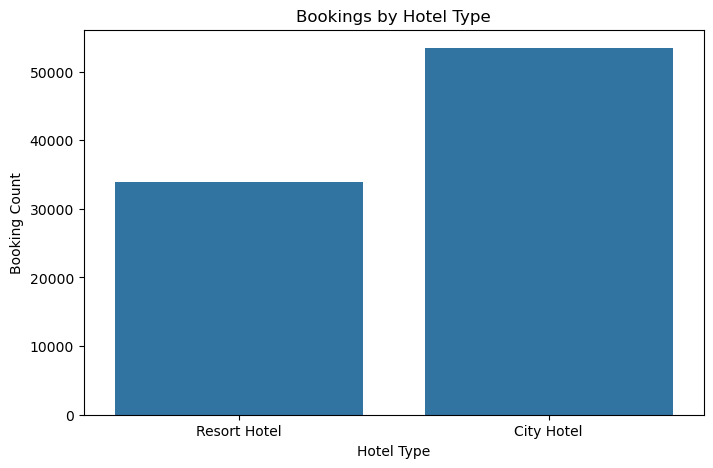

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='hotel',
    data=df
)

plt.title("Bookings by Hotel Type")

plt.xlabel("Hotel Type")

plt.ylabel("Booking Count")

plt.show()

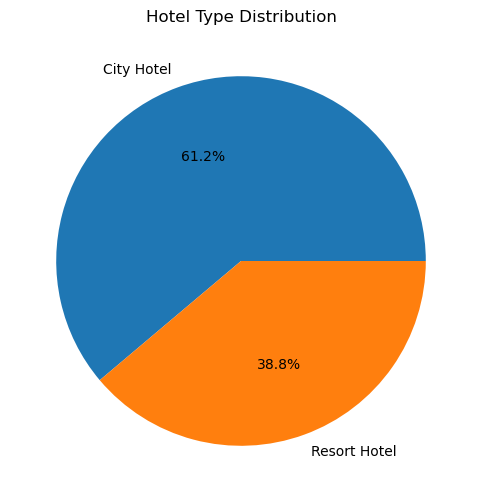

In [7]:
hotel_counts = df['hotel'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    hotel_counts,
    labels=hotel_counts.index,
    autopct="%1.1f%%"
)

plt.title("Hotel Type Distribution")

plt.show()

## Cancellation Rate by Hotel Type

In [8]:
hotel_cancel = (
    df.groupby('hotel')['is_canceled']
    .mean()
    * 100
)

hotel_cancel

hotel
City Hotel      30.041368
Resort Hotel    23.497171
Name: is_canceled, dtype: float64

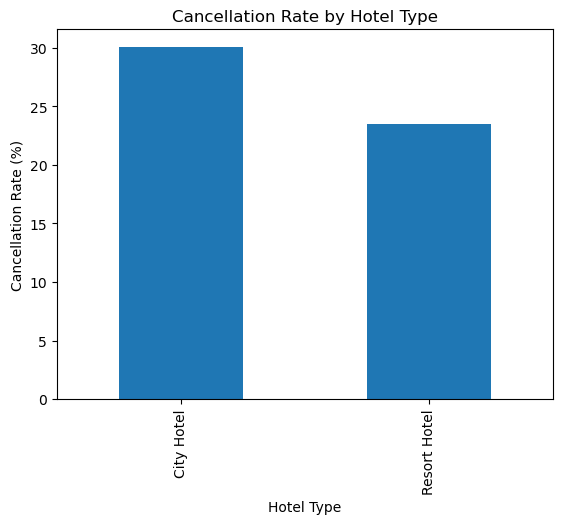

In [9]:
hotel_cancel.plot(
    kind='bar'
)

plt.title(
    "Cancellation Rate by Hotel Type"
)

plt.xlabel(
    "Hotel Type"
)

plt.ylabel(
    "Cancellation Rate (%)"
)

plt.show()

In [10]:
df.groupby('hotel')['adr'].mean()

hotel
City Hotel      110.495901
Resort Hotel     97.223876
Name: adr, dtype: float64

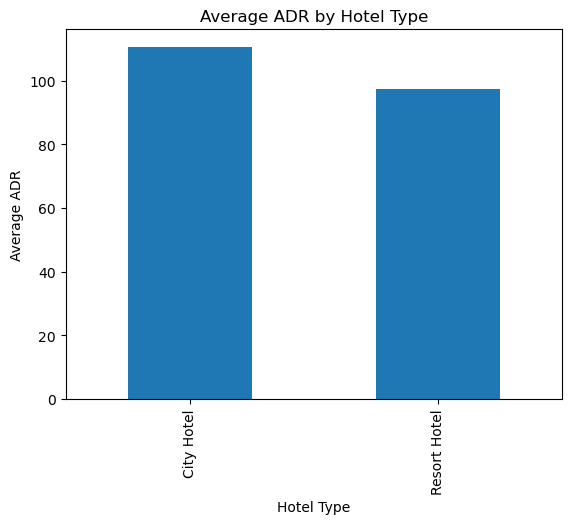

In [11]:
adr_by_hotel = (
    df.groupby('hotel')['adr']
    .mean()
)

adr_by_hotel.plot(
    kind='bar'
)

plt.title(
    "Average ADR by Hotel Type"
)

plt.xlabel(
    "Hotel Type"
)

plt.ylabel(
    "Average ADR"
)

plt.show()

## Business Interpretation

Comparing hotel types helps identify:

- Which hotel receives more bookings.
- Which hotel experiences more cancellations.
- Whether pricing differs significantly between hotel categories.

These insights support revenue optimization and customer retention strategies.

In [12]:
summary = df.groupby('hotel').agg({
    'is_canceled':'mean',
    'adr':'mean',
    'lead_time':'mean'
})

summary

,is_canceled,adr,lead_time
hotel,,,
City Hotel,0.300414,110.495901,77.681710
Resort Hotel,0.234972,97.223876,83.430133


In [13]:
summary['is_canceled'] = (
    summary['is_canceled']
    * 100
)

summary

,is_canceled,adr,lead_time
hotel,,,
City Hotel,30.041368,110.495901,77.681710
Resort Hotel,23.497171,97.223876,83.430133


## Findings

- Booking distribution across hotel types was analyzed.
- Cancellation rates were compared.
- Average ADR was compared.
- Average lead time was compared.
- Significant behavioral differences between hotel categories were identified.

## Day 2 Conclusion

Hotel type analysis revealed differences in booking volume, cancellation behavior, and pricing patterns between City Hotels and Resort Hotels.

These findings provide valuable insights for revenue management and customer retention planning.